# 01 Pubtator Metrics
* Purpose: Investigate how the Pubtator 3 relation extraction model was trained and how it performs in practice. 
* Goal: Identify its strengths and shortcomings so that a better relation extraction tool can be developed moving forward. 

In [15]:
import pandas as pd
import gzip
from tqdm import tqdm
import os
from pathlib import Path


from collections import Counter
from collections import defaultdict
import matplotlib.pyplot as plt


import numpy as np
import ijson
import json
import collections




In [3]:
# Dynamically find the directory where this script/notebook lives
current_dir = Path(__file__).resolve().parent if '__file__' in locals() else Path.cwd()
PROJECT_ROOT = current_dir.parent
PROJECT_ROOT

WindowsPath('d:/Users/Jessica/kg-construction')

In [139]:
def load_biorex_train(train_path):
    parsed_rows = []

    with open(train_path, "r", encoding="utf-8") as handle:
        for line in handle:
            columns = line.rstrip("\n").split("\t")
            if len(columns) <= 7:
                continue

            parsed_rows.append(
                {
                    "pmid": columns[0],
                    "entity_type_1": columns[1],
                    "entity_type_2": columns[2],
                    "context_text": columns[7],
                    "relation_type": columns[-1],
                }
            )

    return pd.DataFrame(parsed_rows)


def normalize_relation_types(df, drop_none=False):
    normalized = df.copy()

    normalized.loc[
        normalized["relation_type"].str.contains("None", case=False, na=False),
        "relation_type",
    ] = "None"
    normalized.loc[
        normalized["relation_type"].str.contains("Association", case=False, na=False),
        "relation_type",
    ] = "Association"

    if drop_none:
        normalized = normalized[normalized["relation_type"] != "None"].copy()

    return normalized


def read_gzip_pmids(path):
    pmids = set()

    with gzip.open(path, "rt", encoding="utf-8") as handle:
        with tqdm(total=os.path.getsize(path), unit="B", unit_scale=True, desc=f"Reading {path.name}") as pbar:
            for line in handle:
                pmids.add(line.split("\t", 1)[0])
                pbar.update(len(line.encode("utf-8")))

    return pmids


def count_gzip_relations(path):
    relation_counter = Counter()

    with gzip.open(path, "rt", encoding="utf-8") as handle:
        with tqdm(total=os.path.getsize(path), unit="B", unit_scale=True, desc=f"Reading {path.name}") as pbar:
            for line in handle:
                parts = line.rstrip("\n").split("\t")
                if len(parts) >= 2:
                    relation_counter[parts[1]] += 1
                pbar.update(len(line.encode("utf-8")))

    return relation_counter


def summarize_relation_counts(counts):
    summary_df = pd.DataFrame(counts, columns=["relation_type", "Count"]).set_index("relation_type")
    total_count = summary_df["Count"].sum()
    summary_df["Percentage"] = (summary_df["Count"] / total_count * 100).round(2).astype(str) + "%"
    return summary_df


def map_pubtator_counts(sorted_counts, mapping):
    mapped_counts = defaultdict(int)

    for relation, count in sorted_counts:
        mapped_counts[mapping[relation]] += count

    mapped_counts["Conversion"] = 0
    return sorted(mapped_counts.items(), key=lambda item: item[1], reverse=True)

### BioREx Training Data Relation Type Counts
Steps:
* Loaded the harmonized training dataset for BioREx and tallied the different relation type counts
* Ensured that all rows in the training dataset were accounted for
* Grouped the "None" and "Association" labels to get a final count

Observations:
* 76.46% of all labels were None and 12% were Associate --> this is in line with what we observed with Pubtator across 33 million abstracts
* The lowest occurence relation labels (Bind, Cotreatment, Comparison, Drug-Interaction, Conversion) are represented at such low frequencies they are practically not present in the training data --> this leaves only 3 relation types: Associate, positive correlation, and negative correlation
* While the training data has only 8 relation types, Pubtator has 12. A clear example is how prevent, inhibit, and negative correlation all map to negative correlate, the difference is in their entity pair types. 
    - Get the counts of the unique entity + relation combinations. Disregarding entity directionality

How to Address this Issue with BioREx:
* Entity pairs can be noisy. Relations likely do not exist for many pairs. One way of reducing the noisiness of entity pairs is to restrict to sentence-level relations. Restrict entity pairs to those that appear in the same sentence or within a certain token span of each other.
* Reduce the number of negative examples in the training data. Right now the training data is disproportionately negative
* Decouple whether or not there is an association from association type. First train a binary classifier to determine whether or not there is an association at all, and then train another model to perform more fine-grained relation type determination.

In [140]:
harmonized_train_path = PROJECT_ROOT / "data" / "00_raw" / "biorex" / "biorex" / "processed" / "train.tsv"

df_harm = load_biorex_train(harmonized_train_path)

print("\n--- Final Confirmed Relation Distribution ---")
print(df_harm["relation_type"].value_counts())


--- Final Confirmed Relation Distribution ---
relation_type
None-BC7                44961
None                    18723
None-DDI                18686
Association             13532
Negative_Correlation     8387
None-CID                 7112
Positive_Correlation     6299
None-AIMED               3288
None-HPRD50              2191
AIMED-Association         748
HPRD-Association          137
Bind                       60
Cotreatment                31
Comparison                 28
Drug_Interaction           11
Conversion                  3
Name: count, dtype: int64


In [141]:
relation_sum = df_harm["relation_type"].value_counts().sum()
total_rows = len(df_harm)

print(f"Are all rows accounted for?: {relation_sum == total_rows}")
print(f"Relation count: {relation_sum:,}")
print(f"Total rows: {total_rows:,}")

Are all rows accounted for?: True
Relation count: 124,197
Total rows: 124,197


In [154]:
df_mapped = normalize_relation_types(df_harm)

# Remove the "None" relation type from df_mapped
df_mapped = df_mapped[df_mapped["relation_type"] != "None"]

biorex_counts = df_mapped["relation_type"].value_counts()
biorex_percentages = df_mapped["relation_type"].value_counts(normalize=True) * 100

biorex_summary_df = pd.DataFrame(
    {
        "Count": biorex_counts,
        "Percentage": biorex_percentages.round(2).astype(str) + "%",
    }
)

print("--- New Standardized Relation Summary ---")
print(biorex_summary_df)

--- New Standardized Relation Summary ---
                      Count Percentage
relation_type                         
Association           14417     49.31%
Negative_Correlation   8387     28.69%
Positive_Correlation   6299     21.55%
Bind                     60      0.21%
Cotreatment              31      0.11%
Comparison               28       0.1%
Drug_Interaction         11      0.04%
Conversion                3      0.01%


In [173]:
df_mapped_with_none = normalize_relation_types(df_harm)
df_mapped_with_none

,pmid,entity_type_1,entity_type_2,context_text,relation_type
0,10491763,GeneOrGeneProduct,GeneOrGeneProduct,What is [Litcoin] between @GeneOrGeneProductSr...,None
1,10491763,GeneOrGeneProduct,GeneOrGeneProduct,What is [Litcoin] between @GeneOrGeneProductSr...,None
2,10491763,ChemicalEntity,GeneOrGeneProduct,What is [Litcoin] between @ChemicalEntitySrc$ ...,None
3,10491763,GeneOrGeneProduct,GeneOrGeneProduct,What is [Litcoin] between @GeneOrGeneProductSr...,None
4,10491763,ChemicalEntity,GeneOrGeneProduct,What is [Litcoin] between @ChemicalEntitySrc$ ...,None
...,...,...,...,...,...
124192,31616045,Chemical,Gene,What is [Litcoin] between @ChemicalEntitySrc$ ...,Association
124193,32423989,Chemical,Gene,What is [Litcoin] between @ChemicalEntitySrc$ ...,Association
124194,32423989,Chemical,Gene,What is [Litcoin] between @ChemicalEntitySrc$ ...,Association
124195,32838647,Chemical,Gene,What is [Litcoin] between @ChemicalEntitySrc$ ...,Association


In [ ]:
# 1. Group by PMID to get the set of unique relation types per paper
grouped_relations = df_mapped_with_none.groupby("pmid")["relation_type"].apply(set)

# 2. Identify PMIDs that ONLY have the 'None' relation
none_only_pmids = grouped_relations[grouped_relations == {"None"}].index.tolist()

total_unique_pmids = len(grouped_relations)
none_only_pmids_count = len(none_only_pmids)
none_only_percentage = (none_only_pmids_count / total_unique_pmids) * 100 if total_unique_pmids > 0 else 0

# 3. Compute general summary stats per PMID (total rows/pairs evaluated per paper)
stats_per_pmid = df_mapped_with_none.groupby("pmid").size().describe()

# --- Print Reports ---
print("=== Summary Stats Per PMID (Evaluated Pairs Per Paper) ===")
print(stats_per_pmid.to_string())

print("\n=== 'None' Relation Type Analysis ===")
print(f"• PMIDs containing ONLY 'None' relations: {none_only_pmids_count}")
print(f"• Total unique PMIDs in DataFrame:       {total_unique_pmids}")
print(f"• Percentage of pure 'None' papers:       {none_only_percentage:.2f}%")

print("\n=== Sample PMIDs with ONLY 'None' Relations ===")
if none_only_pmids_count > 0:
    # Take up to 3 sample PMIDs
    sample_pmids = none_only_pmids[:3]
    print(f"Sample PMIDs identified: {sample_pmids}\n")
    
    # Filter the original DataFrame to show rows from these sample PMIDs
    # Displaying the first 2 rows for each sample to show the structure
    example_df = df_mapped_with_none[df_mapped_with_none["pmid"].isin(sample_pmids)]
    display_df = example_df.groupby("pmid").head(2)
    
    print(display_df[["pmid", "entity_type_1", "entity_type_2", "relation_type"]].to_string(index=False))
else:
    print("No PMIDs found with exclusively 'None' relations.")

=== Summary Stats Per PMID (Evaluated Pairs Per Paper) ===
count    10308.000000
mean        12.048603
std         34.872074
min          1.000000
25%          1.000000
50%          3.000000
75%         12.000000
max       1485.000000

=== 'None' Relation Type Analysis ===
• PMIDs containing ONLY 'None' relations: 2771
• Total unique PMIDs in DataFrame:       10308
• Percentage of pure 'None' papers:       26.88%

=== Sample PMIDs with ONLY 'None' Relations ===
Sample PMIDs identified: ['10000001', '10000002', '10000003']

    pmid entity_type_1 entity_type_2 relation_type
10000001          drug          drug          None
10000002          drug          drug          None
10000002          drug          drug          None
10000003          drug          drug          None
10000003          drug          drug          None


### Pubtator 3 Relation Type Counts
Observations
* 70.8% of papers have zero relations. This is comparable to the percentage of None labels in the training data (76.46%)
* Pubtator does not include none as a relation type, but these numbers add up well.

In [143]:
# Use the slash operator to build the paths relative to the project root
pubtator_relation_path = PROJECT_ROOT / "data" / "00_raw" / "pubtator" / "relation2pubtator3.gz"
pubtator_concepts_path = PROJECT_ROOT / "data" / "00_raw" / "pubtator" / "bioconcepts2pubtator3.gz"

In [144]:
pmids = read_gzip_pmids(pubtator_relation_path)
print(f"Unique PMIDs with relations: {len(pmids):,}")

Reading relation2pubtator3.gz: 2.26GB [01:22, 27.3MB/s]                           

Unique PMIDs with relations: 10,011,206


In [145]:
concepts_pmids = read_gzip_pmids(pubtator_concepts_path)
no_relation_pmids = concepts_pmids - pmids

print(f"Total processed: {len(concepts_pmids):,}")
print(f"No relations: {len(no_relation_pmids):,} ({len(no_relation_pmids) / len(concepts_pmids):.1%})")

Reading bioconcepts2pubtator3.gz: 25.2GB [16:13, 25.9MB/s]                            


Total processed: 34,233,775
No relations: 24,228,823 (70.8%)


In [146]:
relation_counter = count_gzip_relations(pubtator_relation_path)

Reading relation2pubtator3.gz: 2.26GB [02:00, 18.8MB/s]                           


In [147]:
sorted_pubtator_counts = relation_counter.most_common()
labels = [relation for relation, _ in sorted_pubtator_counts]
counts = [count for _, count in sorted_pubtator_counts]
sorted_pubtator_counts

[('associate', 18364211),
 ('treat', 7215596),
 ('negative_correlate', 4035928),
 ('cause', 3708580),
 ('positive_correlate', 3421551),
 ('stimulate', 777214),
 ('inhibit', 615100),
 ('cotreat', 557789),
 ('compare', 533700),
 ('interact', 261823),
 ('prevent', 33960),
 ('drug_interact', 7607)]

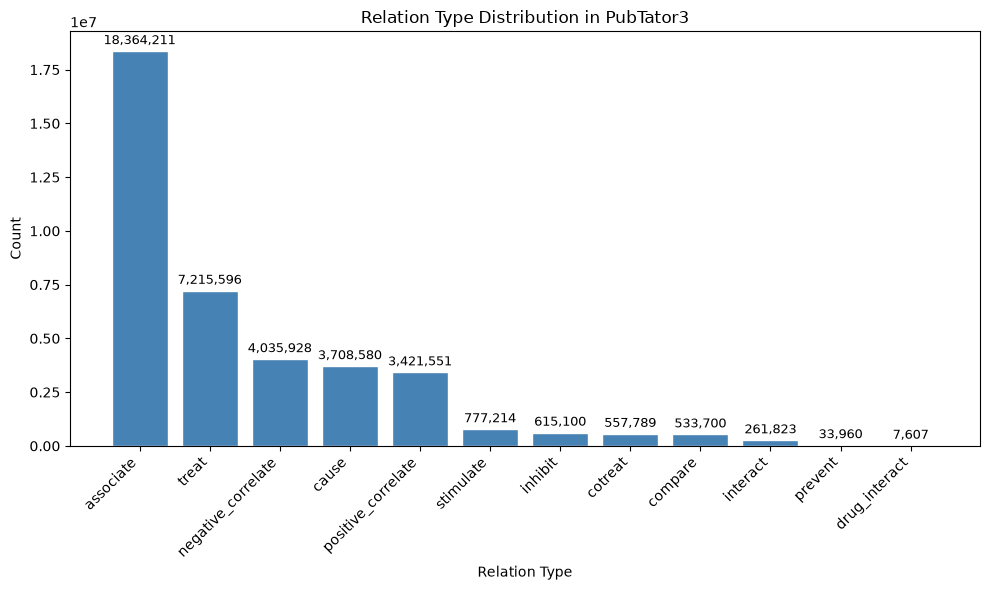

In [148]:
# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(labels, counts, color='steelblue', edgecolor='white')
ax.set_xlabel("Relation Type")
ax.set_ylabel("Count")
ax.set_title("Relation Type Distribution in PubTator3")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')

for i, count in enumerate(counts):
    ax.text(i, count + max(counts)*0.01, f'{count:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Mapping Pubtator to BioREx Relations
* BioREx Relations
    * Association
    * Positive correlation
    * Negative correlation
    * Bind
    * Drug-interaction
    * Co-treatment
    * Comparison
    * Conversion
* Pubtator 
    * Associate (no specific description, applies to various entity pairs) --> Association
    * Cause (positive correlation, chemical-diseases and diseases-variants) --> Positive correlation
    * Compare (comparison, chemical/drug-chemical/drug) --> Comparison
    * Cotreat (two or more chemical/drugs administered separately or in a fixed-dose combination) --> Co-treatment
    * Drug interact (pharmacodynamic interaction between two chemicals) --> Drug-interaction
    * Inhibit (negative correlation, disease-gene and chemical-variant) --> Negative correlation
    * Interact (Physical interaction, like protein-binding. gene-gene, gene-chemical, chemical-variant) --> Bind
    * Negative correlate (chemical-gene, chemical co-expression, and gene co-expression) --> Negative correlation
    * Positive correlate (chemical-gene, chemical co-expression, and gene co-expression) --> Positive correlation
    * Prevent (negative correlation, variant-disease) --> Negative correlation
    * Stimulate (positive correlation, disease-gene and disease-variant) --> Positive correlation
    * Treat (negative correlation, chemical-disease) --> Negative correlation
* I tried mapping BioREx to Pubtator by taking into account the entity types
    * Association, None, drug-interaction, co-treatment, comparison map directly
    * Bind maps to Interact
    * positive correlation and negative correlation require more detailed mapping
    * I got stuck at the relation "prevent" which is only for varient-disease pairs. 
    * "Variant" is not labeled as a separate entity type. Rather it is lumped with Genes and labelled as "GeneOrGeneProduct". It would be a much more involved process to separate out the variants from the genes
* Upon second thought, I think it makes more sense to map Pubtator relation type to BioREx, as BioREx is in fact only designed to identify 8 different relations (9 if including "none")
    * Increasing the granularity of BioREx relations to match Pubtator relations artificially inflates the apparent class counts
    * none --> None
        * THIS DOESNT WORK! I can't count the number of none relations extracted by Pubtator because these are not specified. The none relations are missing, I cannot know how many are missing. The number I do have is the number of papers with 0 extractions. 
        * Compare the percentages across the different relation types but exclude the none label from the biorex training dataset
    * associate --> Association
    * treat, negative_correlate, inhibit, prevent --> Negative_Correlation
    * cause, positive_correlate, stimulate --> Positive_Correlation
    * cotreat --> Cotreatment
    * compare --> Comparison
    * interact --> Bind
    * drug_interact --> Drug_Interaction
    * Notably, no relation in the Pubtator list maps to the relation conversion in the BioREx list. However, this paper (https://arxiv.org/pdf/2305.14259) lists conversion as one of Pubtator 3's 13 relation types

In [149]:
mapping = {
    "associate": "Association",
    "treat": "Negative_Correlation",
    "negative_correlate": "Negative_Correlation",
    "inhibit": "Negative_Correlation",
    "prevent": "Negative_Correlation",
    "cause": "Positive_Correlation",
    "positive_correlate": "Positive_Correlation",
    "stimulate": "Positive_Correlation",
    "cotreat": "Cotreatment",
    "compare": "Comparison",
    "interact": "Bind",
    "drug_interact": "Drug_Interaction",
}

In [150]:
final_counts = map_pubtator_counts(sorted_pubtator_counts, mapping)

for label, count in final_counts:
    print(f"{label}: {count}")

Association: 18364211
Negative_Correlation: 11900584
Positive_Correlation: 7907345
Cotreatment: 557789
Comparison: 533700
Bind: 261823
Drug_Interaction: 7607
Conversion: 0


In [155]:
pubtator_summary_df = summarize_relation_counts(final_counts)
print("--- New Standardized Relation Summary ---")
print(pubtator_summary_df)

--- New Standardized Relation Summary ---
                         Count Percentage
relation_type                            
Association           18364211     46.45%
Negative_Correlation  11900584      30.1%
Positive_Correlation   7907345      20.0%
Cotreatment             557789      1.41%
Comparison              533700      1.35%
Bind                    261823      0.66%
Drug_Interaction          7607      0.02%
Conversion                   0       0.0%


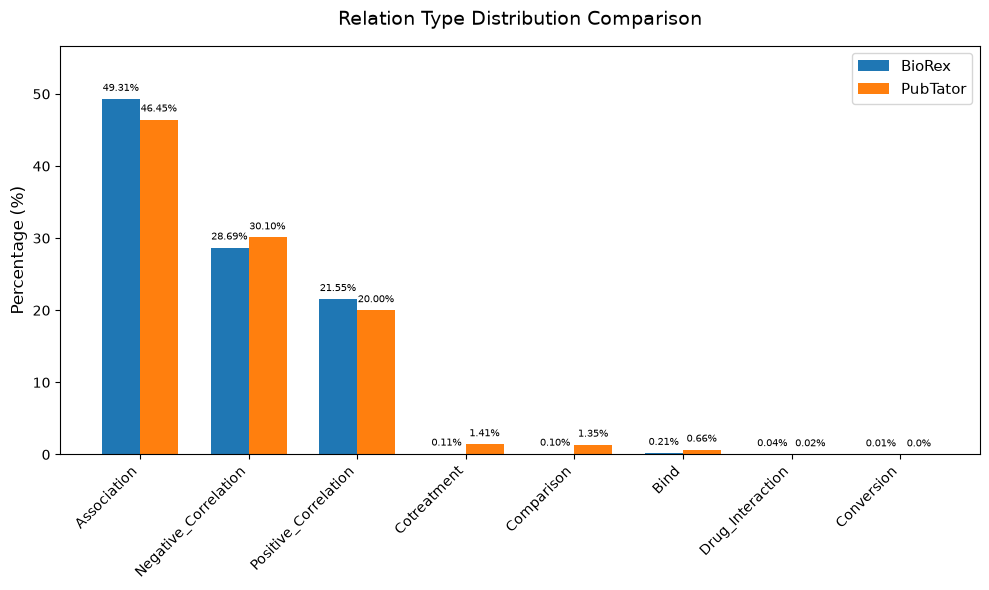

In [156]:
# 1. Clean up and convert 'Percentage' strings to floats
pubtator_summary_df["Pct_Float"] = (
    pubtator_summary_df["Percentage"].str.rstrip("%").astype(float)
)
biorex_summary_df["Pct_Float"] = (
    biorex_summary_df["Percentage"].str.rstrip("%").astype(float)
)

# 2. Combine both into a single DataFrame to ensure perfect index alignment
df_plot = pd.DataFrame(
    {
        "PubTator": pubtator_summary_df["Pct_Float"],
        "BioRex": biorex_summary_df["Pct_Float"],
    }
).fillna(0)

# 3. Sort by PubTator percentages in descending order to keep bars sorted
df_plot = df_plot.sort_values(by="PubTator", ascending=False)

# 4. Create the side-by-side bar plot
fig, ax = plt.subplots(figsize=(10, 6))  # Slightly widened to handle tiny text labels

x = np.arange(len(df_plot.index))
width = 0.35

# Plot bars
rects1 = ax.bar(
    x - width / 2, df_plot["BioRex"], width, label="BioRex", color="#1f77b4"
)
rects2 = ax.bar(
    x + width / 2, df_plot["PubTator"], width, label="PubTator", color="#ff7f0e"
)

# Add labels, title, and custom x-axis tick labels
ax.set_ylabel("Percentage (%)", fontsize=12)
ax.set_title("Relation Type Distribution Comparison", fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(df_plot.index, rotation=45, ha="right", fontsize=10)

# Give the y-axis a little bit of breathing room at the top for labels on the highest bars
ax.set_ylim(0, df_plot.max().max() * 1.15)
ax.legend(fontsize=11)


# Helper function to attach a text label above EVERY bar
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        # Force a label on everything, including 0.0%
        ax.annotate(
            f"{height:.2f}%" if height > 0 else "0.0%",
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 4),  # 4 points vertical offset to keep it clean
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=7.5,  # Slightly smaller font so tiny bars don't overlap
            rotation=0,
        )


autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
# plt.savefig("relation_type_comparison.png", dpi=300)

### BioRED Relation Type Distribution

In [21]:
def parse_pubtator_file(file_path):
    """
    Parses a single PubTator file and returns:
    - all_pmids: set of all PMIDs seen
    - paper_data: dict containing the raw sets of entities and relations per PMID
    """
    if not os.path.exists(file_path):
        print(f"Warning: File not found at {file_path}")
        return None, None

    paper_data = defaultdict(lambda: {'entities': set(), 'relations': set()})
    all_pmids = set()

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            
            # 1. Parse Title and Abstract lines to capture PMIDs
            if '|t|' in line or '|a|' in line:
                pmid = line.split('|')[0]
                all_pmids.add(pmid)
                continue
            
            # 2. Parse tab-separated Entity and Relation lines
            parts = line.split('\t')
            if len(parts) >= 5:
                pmid = parts[0]
                all_pmids.add(pmid)
                
                # Check if it's an entity line (starts with numeric offsets)
                if parts[1].isdigit() and parts[2].isdigit():
                    entity_id = parts[5]
                    # Handles composite IDs like 'D004409;D006948'
                    for individual_id in entity_id.split(';'):
                        paper_data[pmid]['entities'].add(individual_id.strip())
                else:
                    # It's a relation line: RelationType, ID1, ID2
                    rel_type = parts[1]
                    id1 = parts[2]
                    id2 = parts[3]
                    paper_data[pmid]['relations'].add((rel_type, id1, id2))

    return all_pmids, paper_data

def calculate_spread_metrics(data_list):
    """
    Calculates median, min, max, and IQR for a list of numbers.
    """
    if not data_list:
        return {"median": 0, "min": 0, "max": 0, "q1": 0, "q3": 0, "iqr": 0}
    
    arr = np.array(data_list)
    q1 = np.percentile(arr, 25)
    q3 = np.percentile(arr, 75)
    
    return {
        "median": np.median(arr),
        "min": np.min(arr),
        "max": np.max(arr),
        "q1": q1,
        "q3": q3,
        "iqr": q3 - q1
    }

# File paths
file_paths = {
    "Dev": r"D:\Users\Jessica\kg-construction\data\00_raw\biorex\ncbi_relation\Dev.PubTator",
    "Test": r"D:\Users\Jessica\kg-construction\data\00_raw\biorex\ncbi_relation\Test.PubTator",
    "Train": r"D:\Users\Jessica\kg-construction\data\00_raw\biorex\ncbi_relation\Train.PubTator"
}

if __name__ == "__main__":
    global_entity_counts = []
    global_relation_counts = []

    # --- PART 1: Process Each Dataset & Print Samples ---
    for dataset_name, path in file_paths.items():
        print(f"=== Processing Dataset: {dataset_name} ===")
        all_pmids, paper_data = parse_pubtator_file(path)
        
        if not all_pmids:
            continue
            
        total_papers = len(all_pmids)
        print(f"Total Papers in {dataset_name}: {total_papers}\n")
        
        print(f"{'PMID':<12} | {'Unique Entities':<15} | {'Unique Relations':<16}")
        print("-" * 50)
        
        # Display only the first 3 papers as samples
        sample_pmids = sorted(list(all_pmids))[:3]
        for pmid in sample_pmids:
            metrics = paper_data[pmid]
            ent_count = len(metrics['entities'])
            rel_count = len(metrics['relations'])
            print(f"{pmid:<12} | {ent_count:<15} | {rel_count:<16}")
        print(f"... ({total_papers - 3} more papers omitted from visualization) ...")
        print("\n" + "="*50 + "\n")
        
        # Accumulate metrics for overall stats across everything
        for pmid in all_pmids:
            global_entity_counts.append(len(paper_data[pmid]['entities']))
            global_relation_counts.append(len(paper_data[pmid]['relations']))

    # --- PART 2: Global Collective Statistics ---
    entity_stats = calculate_spread_metrics(global_entity_counts)
    relation_stats = calculate_spread_metrics(global_relation_counts)
    
    # Calculate zero relation metadata
    zero_relation_papers = sum(1 for count in global_relation_counts if count == 0)
    total_papers_global = len(global_relation_counts)
    zero_relation_pct = (zero_relation_papers / total_papers_global) * 100 if total_papers_global > 0 else 0

    print(f"=== Combined Statistics Across All Datasets (Total Papers: {total_papers_global}) ===\n")

    print("UNIQUE ENTITIES PER PAPER")
    print(f"  • Median: {entity_stats['median']:.1f}")
    print(f"  • Spread Range: {entity_stats['min']} to {entity_stats['max']}")
    print(f"  • Interquartile Range (IQR): {entity_stats['iqr']:.1f} (Q1-Q3 Range: {entity_stats['q1']:.1f} - {entity_stats['q3']:.1f})")

    print("\nUNIQUE RELATIONS PER PAPER")
    print(f"  • Median: {relation_stats['median']:.1f}")
    print(f"  • Spread Range: {relation_stats['min']} to {relation_stats['max']}")
    print(f"  • Interquartile Range (IQR): {relation_stats['iqr']:.1f} (Q1-Q3 Range: {relation_stats['q1']:.1f} - {relation_stats['q3']:.1f})")

    print("\nZERO RELATION ABSTRACTS")
    print(f"  • Count: {zero_relation_papers} papers out of {total_papers_global}")
    print(f"  • Percentage: {zero_relation_pct:.2f}% of the overall corpus")

=== Processing Dataset: Dev ===
Total Papers in Dev: 100

PMID         | Unique Entities | Unique Relations
--------------------------------------------------
14510914     | 14              | 12              
15018851     | 12              | 10              
15041272     | 12              | 8               
... (97 more papers omitted from visualization) ...


=== Processing Dataset: Test ===
Total Papers in Test: 100

PMID         | Unique Entities | Unique Relations
--------------------------------------------------
15000256     | 6               | 6               
15036754     | 20              | 25              
15111599     | 9               | 6               
... (97 more papers omitted from visualization) ...


=== Processing Dataset: Train ===
Total Papers in Train: 400

PMID         | Unique Entities | Unique Relations
--------------------------------------------------
10491763     | 9               | 3               
10661407     | 2               | 1               
10788334 

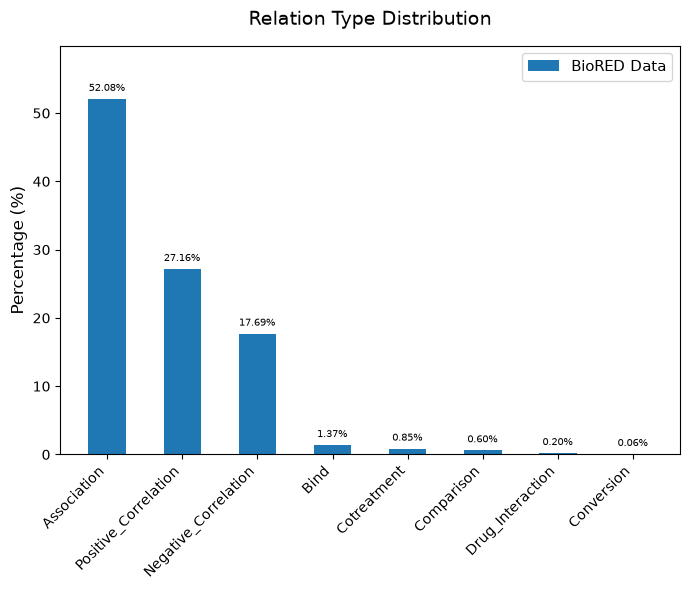

In [163]:
def count_relation_types(file_paths):
    """
    Parses PubTator files and counts the total occurrences of each relation type.
    """
    relation_counts = Counter()
    total_relations = 0
    
    for dataset_name, path in file_paths.items():
        if not os.path.exists(path):
            print(f"Warning: File not found at {path}")
            continue
            
        with open(path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line or '|t|' in line or '|a|' in line:
                    continue
                
                parts = line.split('\t')
                if len(parts) == 5 and not (parts[1].isdigit() and parts[2].isdigit()):
                    rel_type = parts[1]
                    relation_counts[rel_type] += 1
                    total_relations += 1
                    
    return relation_counts, total_relations

def plot_relation_percentages(relation_counts, total_relations):
    """
    Generates and saves a styled bar plot matching the comparison style logic.
    """
    if total_relations == 0:
        print("No relations found to plot.")
        return
        
    # 1. Build a Pandas DataFrame to align with your processing style
    data = []
    for rel, count in relation_counts.items():
        pct = (count / total_relations) * 100
        data.append({"Relation_Type": rel, "Pct_Float": pct})
        
    df_plot = pd.DataFrame(data).set_index("Relation_Type")
    
    # 2. Sort by percentages in descending order to keep bars sorted
    df_plot = df_plot.sort_values(by="Pct_Float", ascending=False)
    
    # 3. Create the single-colored bar plot using your exact sizing and configuration
    fig, ax = plt.subplots(figsize=(7, 6)) # Widened to handle text labels cleanly
    
    x = np.arange(len(df_plot.index))
    width = 0.5  # Solid, clear single bar width
    
    # Plot bars using the classic Blue hex color from your comparison code
    rects = ax.bar(
        x, df_plot["Pct_Float"], width, label="BioRED Data", color="#1f77b4"
    )
    
    # Add labels, title, and custom x-axis tick labels
    ax.set_ylabel("Percentage (%)", fontsize=12)
    ax.set_title("Relation Type Distribution", fontsize=14, pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(df_plot.index, rotation=45, ha="right", fontsize=10)
    
    # Give the y-axis a little bit of breathing room at the top for labels
    ax.set_ylim(0, df_plot["Pct_Float"].max() * 1.15)
    ax.legend(fontsize=11)
    
    # Helper function to attach a text label above EVERY bar matching your font logic
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            # Force a label on everything, including 0.0%
            ax.annotate(
                f"{height:.2f}%" if height > 0 else "0.0%",
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 4),  # 4 points vertical offset to keep it clean
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=7.5,   # Slightly smaller font so tiny bars don't overlap
                rotation=0,
            )

    autolabel(rects)
    
    plt.tight_layout()
    
    # output_filename = 'relation_type_distribution.png'
    # plt.savefig(output_filename, dpi=300)
    # print(f"Success: Plot saved as '{output_filename}'")

# Local dataset paths
file_paths = {
    "Dev": r"D:\Users\Jessica\kg-construction\data\00_raw\biorex\ncbi_relation\Dev.PubTator",
    "Test": r"D:\Users\Jessica\kg-construction\data\00_raw\biorex\ncbi_relation\Test.PubTator",
    "Train": r"D:\Users\Jessica\kg-construction\data\00_raw\biorex\ncbi_relation\Train.PubTator"
}

if __name__ == "__main__":
    counts, total = count_relation_types(file_paths)
    plot_relation_percentages(counts, total)

In [25]:
from collections import defaultdict, Counter
import os
import xml.etree.ElementTree as ET
import time
import numpy as np
import requests

# (Keep your existing parse_pubtator_file and calculate_spread_metrics functions here)

def fetch_pubmed_metadata(pmids, batch_size=200):
    """
    Fetches MeSH terms and Publication Types from NCBI E-utilities in batches.
    Returns:
    - mesh_data: dict of PMID -> list of MeSH terms
    - pub_types: dict of PMID -> list of Publication Types
    """
    mesh_data = defaultdict(list)
    pub_types = defaultdict(list)
    
    pmid_list = list(pmids)
    total = len(pmid_list)
    print(f"Fetching metadata from NCBI for {total} unique PMIDs...")

    for i in range(0, total, batch_size):
        batch = pmid_list[i:i+batch_size]
        pmid_string = ",".join(batch)
        
        # NCBI E-Fetch URL
        url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi"
        params = {
            "db": "pubmed",
            "id": pmid_string,
            "retmode": "xml"
        }
        
        try:
            response = requests.get(url, params=params)
            if response.status_code != 200:
                print(f"Warning: API returned status code {response.status_code} for batch {i//batch_size + 1}")
                continue
                
            root = ET.fromstring(response.content)
            
            for article in root.findall(".//PubmedArticle"):
                pmid_node = article.find(".//MedlineCitation/PMID")
                if pmid_node is None:
                    continue
                pmid = pmid_node.text
                
                # 1. Extract Publication Types
                for p_type in article.findall(".//PublicationTypeList/PublicationType"):
                    if p_type.text:
                        pub_types[pmid].append(p_type.text)
                        
                # 2. Extract MeSH Terms
                for mesh in article.findall(".//MeshHeadingList/MeshHeading/DescriptorName"):
                    if mesh.text:
                        mesh_data[pmid].append(mesh.text)
                        
        except Exception as e:
            print(f"Error fetching batch starting at index {i}: {e}")
            
        # Respect NCBI rate limits (max 3 requests per second without an API key)
        time.sleep(0.4)
        
    return mesh_data, pub_types

# File paths
file_paths = {
    "Dev": r"D:\Users\Jessica\kg-construction\data\00_raw\biorex\ncbi_relation\Dev.PubTator",
    "Test": r"D:\Users\Jessica\kg-construction\data\00_raw\biorex\ncbi_relation\Test.PubTator",
    "Train": r"D:\Users\Jessica\kg-construction\data\00_raw\biorex\ncbi_relation\Train.PubTator"
}

if __name__ == "__main__":
    global_entity_counts = []
    global_relation_counts = []
    all_unique_pmids = set()

    # --- PART 1: Process Each Dataset ---
    for dataset_name, path in file_paths.items():
        all_pmids, paper_data = parse_pubtator_file(path)
        if not all_pmids:
            continue
            
        all_unique_pmids.update(all_pmids)
        
        for pmid in all_pmids:
            global_entity_counts.append(len(paper_data[pmid]['entities']))
            global_relation_counts.append(len(paper_data[pmid]['relations']))

    # --- PART 2: Fetch MeSH & Publication Type Metadata ---
    mesh_map, pub_type_map = fetch_pubmed_metadata(all_unique_pmids)

    # --- PART 3: Analyze Publication Types & MeSH Distribution ---
    paper_type_counts = Counter()
    global_mesh_counter = Counter()

    for pmid in all_unique_pmids:
        types = pub_type_map.get(pmid, [])
        
        # Count every individual type tag found across all papers
        for t in types:
            paper_type_counts[t] += 1

        # Track MeSH terms
        for term in mesh_map.get(pmid, []):
            global_mesh_counter[term] += 1

    total_papers = len(all_unique_pmids)

    # --- PART 4: Output Insights ---
    print("\n" + "="*50)
    print("=== CORPUS TYPE & CONTENT INSIGHTS ===")
    print("="*50 + "\n")

    print(f"TOP 20 PUBLICATION TYPES (Out of {total_papers} total papers)")
    # Note: Percentages may sum to > 100% since a paper can have multiple tags
    for rank, (p_type, count) in enumerate(paper_type_counts.most_common(20), 1):
        pct = (count / total_papers) * 100 if total_papers > 0 else 0
        print(f"  {rank}. {p_type:<35} | {count:>3} papers ({pct:.2f}%)")

    print(f"\nTOP 20 MOST COMMON MeSH TERMS (Out of {total_papers} total papers)")
    for rank, (term, count) in enumerate(global_mesh_counter.most_common(20), 1):
        pct = (count / total_papers) * 100 if total_papers > 0 else 0
        print(f"  {rank}. {term:<35} | Found in {count:>3} papers ({pct:.2f}%)")

Fetching metadata from NCBI for 600 unique PMIDs...

=== CORPUS TYPE & CONTENT INSIGHTS ===

TOP 20 PUBLICATION TYPES (Out of 600 total papers)
  1. Journal Article                     | 598 papers (99.67%)
  2. Research Support, Non-U.S. Gov't    | 370 papers (61.67%)
  3. Research Support, N.I.H., Extramural | 102 papers (17.00%)
  4. Case Reports                        |  86 papers (14.33%)
  5. Comparative Study                   |  43 papers (7.17%)
  6. Research Support, U.S. Gov't, P.H.S. |  17 papers (2.83%)
  7. Multicenter Study                   |  15 papers (2.50%)
  8. Randomized Controlled Trial         |  15 papers (2.50%)
  9. Research Support, U.S. Gov't, Non-P.H.S. |  12 papers (2.00%)
  10. Research Support, N.I.H., Intramural |  12 papers (2.00%)
  11. Review                              |  10 papers (1.67%)
  12. Clinical Trial                      |   6 papers (1.00%)
  13. Controlled Clinical Trial           |   3 papers (0.50%)
  14. Meta-Analysis               

### iKraph Relation Type Distribution
* DBRelations.json contains "Database-Inferred Relationships"
* PubMedList.json contains PubMed Abstract Relationships

In [ ]:
# Print the first 5 rows from DBRelations.json for viewing
ikraph_DBRelations_path = PROJECT_ROOT / "data" / "00_raw" / "ikraph" / "iKraph_full" / "DBRelations.json"

with open(ikraph_DBRelations_path, 'rb') as f:
    # 'item' assumes the file is a list of objects like: [{"a":1}, {"a":2}, ...]
    # ijson will yield one object at a time as it parses
    parser = ijson.items(f, 'item')
    
    for i, record in enumerate(parser):
        if i >= 5:
            break
        print(record)
        print()

--- Row 1 ---
{'relID': '594356.10468044.2.2.0.Hetionet', 'node_one_id': '594356', 'node_two_id': '10468044', 'node_one_type': 'Gene', 'node_two_type': 'Anatomy', 'node_one_name': 'PGS1', 'node_two_name': 'Blood', 'node_one_subtype': 'NA', 'node_two_subtype': 'NA', 'direction': '0', 'relationship_type': '2', 'prob': Decimal('0.9'), 'method': 'MA', 'source': 'Hetionet', 'correlation_type': '2', 'score': 1}

--- Row 2 ---
{'relID': '4136753.10453136.1.1.0.Hetionet', 'node_one_id': '4136753', 'node_two_id': '10453136', 'node_one_type': 'Gene', 'node_two_type': 'Anatomy', 'node_one_name': 'Urb2', 'node_two_name': 'Female Gonad', 'node_one_subtype': 'NA', 'node_two_subtype': 'NA', 'direction': '0', 'relationship_type': '1', 'prob': Decimal('0.9'), 'method': 'MA', 'source': 'Hetionet', 'correlation_type': '1', 'score': 1}

--- Row 3 ---
{'relID': '4757400.10450938.1.1.0.Hetionet', 'node_one_id': '4757400', 'node_two_id': '10450938', 'node_one_type': 'Gene', 'node_two_type': 'Anatomy', 'node_

In [7]:
# Retrieve all unique sources from the DBRelations.json file and count their occurrences
file_size = os.path.getsize(ikraph_DBRelations_path)
source_counts = Counter()

# Use tqdm to track progress by bytes
with open(ikraph_DBRelations_path, 'rb') as f:
    with tqdm(total=file_size, unit='B', unit_scale=True, desc="Processing DBRelations") as pbar:
        parser = ijson.items(f, 'item')
        
        last_pos = 0
        
        for record in parser:
            # Update the source counts
            source = record.get('source', 'Unknown')
            source_counts[source] += 1
            
            # Update the progress bar based on file position
            current_pos = f.tell()
            pbar.update(current_pos - last_pos)
            last_pos = current_pos

# Print the results
print("\n--- Source Counts ---")
for source, count in source_counts.items():
    print(f"{source}: {count:,}")

Processing DBRelations: 100%|██████████| 6.63G/6.63G [03:42<00:00, 29.8MB/s]


--- Source Counts ---
Hetionet: 2,249,130
primeKG: 4,031,957
TTD: 82,970
PubChem: 4,819,249
GO_annotation: 370,931


In [ ]:
import ijson
import json
from decimal import Decimal

# Helper function to convert Decimal to float for printing
def default_converter(o):
    if isinstance(o, Decimal):
        return float(o)
    raise TypeError(f"Object of type {o.__class__.__name__} is not JSON serializable")

# Print the first 5 rows from DBRelations.json for viewing
ikraph_PubMedList_path = PROJECT_ROOT / "data" / "00_raw" / "ikraph" / "iKraph_full" / "PubMedList.json"

print(f"Reading first 5 items from {ikraph_PubMedList_path}...\n")

with open(ikraph_PubMedList_path, 'rb') as f:
    parser = ijson.items(f, 'item')
    
    for i, record in enumerate(parser):
        if i >= 5:
            break
        
        print(f"--- Row {i+1} ---")
        # Use the default_converter to handle the Decimal type
        print(json.dumps(record, indent=4, default=default_converter))
        print()

Reading first 5 items from d:\Users\Jessica\kg-construction\data\00_raw\ikraph\iKraph_full\PubMedList.json...

--- Row 1 ---
{
    "id": "2273873.408584.3.0.12.MP",
    "list": [
        [
            1239,
            "15040535.408584.2273873",
            0.2545,
            1
        ],
        [
            402,
            "17341536.408584.2273873",
            0.5746,
            1
        ]
    ]
}

--- Row 2 ---
{
    "id": "809.469778.3.0.21.MP",
    "list": [
        [
            383,
            "15535418.809.469778",
            0.8182,
            1
        ]
    ]
}

--- Row 3 ---
{
    "id": "21.470080.2.2.21.MP",
    "list": [
        [
            422,
            "15535418.21.470080",
            0.4245,
            1
        ],
        [
            206,
            "11303038.21.470080",
            0.6872,
            1
        ],
        [
            381,
            "17591029.21.470080",
            0.7846,
            1
        ],
        [
            386,
   

In [16]:
output_path = PROJECT_ROOT / "outputs" / "01_pubtator_metrics" / "ikraph_pubmed_id_counts_20260630.json"

# Ensure the output directory exists
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Counters
counts = {
    "relation_id": collections.Counter(),
    "correlation_id": collections.Counter(),
    "direction": collections.Counter(),
    "method": collections.Counter()
}

print("Scanning PubMedList.json...")

# 2. Wrap the parser in tqdm
# Since ijson doesn't know the file size in items, we set total=None 
# (it will just show progress speed and count)
with open(ikraph_PubMedList_path, 'rb') as f:
    parser = ijson.items(f, 'item')
    
    # tqdm will automatically count the iterations for you
    for record in tqdm(parser, desc="Processing records"):
        parts = record.get('id', '').split('.')
        
        if len(parts) == 6:
            counts["relation_id"][parts[2]] += 1
            counts["correlation_id"][parts[3]] += 1
            counts["direction"][parts[4]] += 1
            counts["method"][parts[5]] += 1

# Save results
with open(output_path, 'w') as f:
    serializable_counts = {k: dict(v) for k, v in counts.items()}
    json.dump(serializable_counts, f, indent=4)

print(f"\nDone! Counts saved to {output_path}")
print("Top Relation IDs found:")
print(counts["relation_id"].most_common(5))

Scanning PubMedList.json...


Processing records: 32991111it [07:16, 75547.09it/s] 


Done! Counts saved to d:\Users\Jessica\kg-construction\outputs\01_pubtator_metrics\ikraph_pubmed_id_counts_20260630.json
Top Relation IDs found:
[('1', 14291966), ('3', 6709476), ('2', 5899437), ('51', 2087800), ('52', 1628290)]


In [17]:
ikraph_RelTypeInt_filepath = PROJECT_ROOT / "data" / "00_raw" / "ikraph" / "iKraph_full" / "RelTypeInt.json"

with open(ikraph_RelTypeInt_filepath, 'r') as f:
    schema = json.load(f)

# Create a mapping dictionary
lookup = {item['intRep']: item['relType'] for item in schema}

# Print the top 5 with names
top_5 = [('1', 14291966), ('3', 6709476), ('2', 5899437), ('51', 2087800), ('52', 1628290)]
for rid, count in top_5:
    print(f"Relation ID {rid} ({lookup.get(rid, 'Unknown')}) appears {count:,} times.")

Relation ID 1 (Association) appears 14,291,966 times.
Relation ID 3 (Negative_Correlation) appears 6,709,476 times.
Relation ID 2 (Positive_Correlation) appears 5,899,437 times.
Relation ID 51 (Target_Disease) appears 2,087,800 times.
Relation ID 52 (Biomarker_Disease) appears 1,628,290 times.


In [18]:
import json
import pandas as pd
import os

# 1. Load the ID counts
count_file = PROJECT_ROOT / "outputs" / "01_pubtator_metrics" / "ikraph_pubmed_id_counts_20260630.json"
with open(count_file, 'r') as f:
    counts_data = json.load(f)
    
# 2. Load the Relation Schema for mapping
schema_file = PROJECT_ROOT / "data" / "00_raw" / "ikraph" / "iKraph_full" / "RelTypeInt.json"
with open(schema_file, 'r') as f:
    schema = json.load(f)

# Create a lookup: { "1": "Association", "2": "Interaction", ... }
lookup = {item['intRep']: item['relType'] for item in schema}

# 3. Convert to DataFrame for all relations
df_rel = pd.DataFrame.from_dict(counts_data['relation_id'], orient='index', columns=['count'])
df_rel.index.name = 'relation_id'

# Map the IDs to Names
df_rel['relation_name'] = df_rel.index.map(lambda x: lookup.get(x, 'Unknown'))

# Sort by count descending (so the most frequent are at the top)
df_rel = df_rel.sort_values(by='count', ascending=False)

# 4. Save the full mapping to a CSV for easy viewing in Excel or plotting later
# output_csv = PROJECT_ROOT / "outputs" / "01_pubtator_metrics" / "full_relation_counts.csv"
# df_rel.to_csv(output_csv)

# print(f"Full breakdown saved to: {output_csv}")
print(df_rel.head(20)) # See the top 20, but the full file is saved

                count         relation_name
relation_id                                
1            14291966           Association
3             6709476  Negative_Correlation
2             5899437  Positive_Correlation
51            2087800        Target_Disease
52            1628290     Biomarker_Disease
4             1183895                  Bind
5              788776           Cotreatment
6              319396            Comparison
7               78961      Drug_Interaction
8                3114            Conversion


In [19]:
unique_pmids = set()
paper_extraction_counts = Counter()  # Tracks how many extractions each PMID has

print("Analyzing extraction productivity...")

with open(ikraph_PubMedList_path, 'rb') as f:
    parser = ijson.items(f, 'item')
    
    for record in tqdm(parser, desc="Processing records"):
        # Access the list of evidence for this relationship
        for evidence in record.get('list', []):
            # DocumentID (e.g., "15040535.408584.2273873")
            # The PMID is the first part before the first dot
            doc_id = evidence[1]
            pmid = doc_id.split('.')[0]
            
            unique_pmids.add(pmid)
            paper_extraction_counts[pmid] += 1

total_pubmed_corpus = 34_000_000 
papers_with_extractions = len(unique_pmids)
zero_extraction_papers = total_pubmed_corpus - papers_with_extractions

print(f"\n--- Extraction Productivity Report ---")
print(f"Total PubMed Papers Analyzed: {total_pubmed_corpus:,}")
print(f"Papers with ≥ 1 extraction:   {papers_with_extractions:,}")
print(f"Papers with 0 extractions:    {zero_extraction_papers:,}")
print(f"Extraction Yield Rate:        {(papers_with_extractions/total_pubmed_corpus)*100:.2f}%")

# Extra: Show average density
avg_extractions_per_productive_paper = sum(paper_extraction_counts.values()) / papers_with_extractions
print(f"Avg. extractions per productive paper: {avg_extractions_per_productive_paper:.2f}")

Analyzing extraction productivity...


Processing records: 32991111it [10:12, 53819.59it/s] 


--- Extraction Productivity Report ---
Total PubMed Papers Analyzed: 34,000,000
Papers with ≥ 1 extraction:   11,471,923
Papers with 0 extractions:    22,528,077
Extraction Yield Rate:        33.74%
Avg. extractions per productive paper: 6.28
